In [1]:
from import_and_plotting_tech import *
import pickle

from ensemble_data import data_16_x_64_1p5Tc as data_ensemble
flowtimes = data_ensemble['flowtimes']

mats_list = [0, 1, 2]
iflows_mats = {
    0 : [11,12,14,16,18],
    1 : [11,12,14,16,18],
    2 : [11,12,14]
}
sub_list = [(0,1), (0,1,2)]

In [2]:
# load bootstrap ensemble
pickle_path = Path.cwd() / '..' / 'data' / 'bs_H.pkl'
with open(pickle_path, 'rb') as f:
    bs_data : list[ResultData] = pickle.load(f)
print('Number of bootstrap samples =', len(bs_data), end='\n\n\n')

# H_n and H_sub from bootstrap ensemble
H_ense = {}
for mats in mats_list:
    for iflow in iflows_mats[mats]:
        H_ense[f'H_{mats}_{iflow}'] = [rd.tsums_mats[iflow,mats] for rd in bs_data]
for sub in sub_list:
    for iflow in set.intersection(*(set(iflows_mats[mats]) for mats in sub)):
        H_ense[f'H_{sub}_{iflow}'] = [rd.tsums_subs[sub,iflow] for rd in bs_data]
H_data = gv.dataset.avg_data(H_ense, bstrap=True)

Number of bootstrap samples = 1000




In [11]:
# which data for fit
sub    = (0,1)
iflows = [14,18]

# x data (flowtimes)
x_data = flowtimes[iflows]
print(f'{x_data = !s}')

# y data (H_sub)
y_ense = np.zeros(shape=(len(bs_data),len(x_data)), dtype=float)
y_data = np.zeros(shape=(len(x_data),), dtype=object)
for iiflow, iflow in enumerate(iflows):
    y_ense[:,iiflow] = H_ense[f'H_{sub}_{iflow}']
    y_data[iiflow]   = H_data[f'H_{sub}_{iflow}']
print(f'{y_data = !s}')

print()
print(gv.evalcov(y_data))
print(gv.evalcorr(y_data))


x_data = [0.58909938 0.9353328 ]
y_data = [-0.0392(72) -0.0404(60)]

[[5.18318648e-05 4.25633465e-05]
 [4.25633465e-05 3.62604874e-05]]
[[1.         0.98179436]
 [0.98179436 1.        ]]


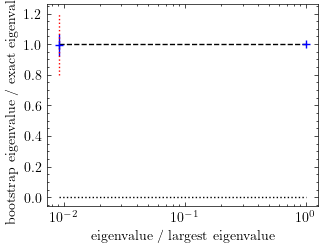

svd.eps=np.float64(0.00918644502726366), svd.nmod=0


In [12]:
# svd analysis
%matplotlib inline
svd = gv.dataset.svd_diagnosis(y_ense, nbstrap=500)
svd.plot_ratio(show=True)

print(f'{svd.eps=}, {svd.nmod=}')

# Eigenvalues and eigenvectors of covariance matrix

In [13]:
eigvals, eigvecs = np.linalg.eig(gv.evalcov(y_data))
for i, ei in enumerate(eigvals):
    print(f'{ei:.8f}   {eigvecs[:,i]}')

0.00008732   [0.76809326 0.64033799]
0.00000078   [-0.64033799  0.76809326]


# Uncertainty and distribution of covariance

[[5.27(25)e-08 4.07(20)e-08]
 [4.07(20)e-08 3.26(16)e-08]]
[[1 ± 2.2e-16 0.9818(12)]
 [0.9818(12) 1 ± 2.2e-16]]


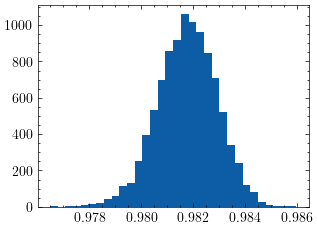

In [15]:
n_bs = 10000

y_cov_bs  = np.zeros(shape=(n_bs, len(y_data), len(y_data)), dtype=float)
y_corr_bs = np.zeros(shape=(n_bs, len(y_data), len(y_data)), dtype=float)

for i_bs, y_bs in enumerate(gv.dataset.bootstrap_iter(y_ense ,n=n_bs)):
    y_cov_bs[i_bs]  = gv.evalcov(gv.dataset.avg_data(y_bs))
    y_corr_bs[i_bs] = gv.evalcorr(gv.dataset.avg_data(y_bs))

y_cov = gv.dataset.avg_data(y_cov_bs, bstrap=True)
print(y_cov)

y_corr = gv.dataset.avg_data(y_corr_bs, bstrap=True)
print(y_corr)

plt.hist(y_corr_bs[:,1,0], bins=32)
plt.show()

fit result = -0.0428(48)


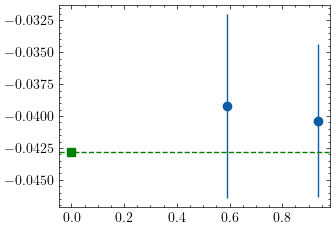

In [24]:
# linear fit analyically (but is exact same as done with lsqfit.nonlinear_fit)
A    = np.ones(shape=(len(x_data),))
V    = gv.evalcov(y_data)
Vinv_A = np.linalg.solve(V, A)
L = Vinv_A.T / (A.T @ Vinv_A)

res = L @ gv.mean(y_data)
cov = 1 / (A.T @ Vinv_A)
err = np.sqrt(cov)
print('fit result =', gv.gvar(res, err))

plt.errorbar(x_data, gv.mean(y_data), gv.sdev(y_data), linestyle='', marker='o')
plt.errorbar(0, res, marker='s', color='green')
plt.axhline(y=res, color='green', linestyle='--')
plt.show()

In [55]:
def do_fit(sub : tuple, iflows : list, model : str) -> lsqfit.nonlinear_fit:
    print(f'\n{model} fit for {sub=} and {iflows=}')

    # x data (flowtimes)
    x_data = flowtimes[iflows]
    # y data (H_sub)
    y_data = np.array([H_data[f'H_{sub}_{iflow}'] for iflow in iflows])

    fcn = {
        'constant'  : lambda x,p : p[0],
        'linear'    : lambda x,p : p[0] + p[1]*x,
        'quadratic' : lambda x,p : p[0] + p[1]*x**2
    }[model]

    fit = lsqfit.nonlinear_fit(
        data = (x_data, y_data),
        fcn = fcn,
        p0 = [0] if model=='constant' else [0,0]
    )

    print(f'chi2/dof [dof] = {fit.chi2/fit.dof:.2f} [{fit.dof}],    Q = {fit.Q:.2f}')
    print(f'f(x) =', {'constant':'a', 'linear':'a + bx', 'quadratic':'a + bx²'}[model], end=',    ')
    print(f'a = {fit.p[0]}' + (f'b = {fit.p[1]}' if model!='constant' else ''))

    return fit


do_fit((0,1), [11,14,18], 'linear')


linear fit for sub=(0, 1) and iflows=[11, 14, 18]
chi2/dof [dof] = 1.07 [1],    Q = 0.30
f(x) = a + bx,    a = -0.0437(73)b = -0.00003(381)


# Constant fits: full cov, different amount of flowtimes


constant fit for sub=(0, 1) and iflows=[14, 18]
chi2/dof [dof] = 0.45 [1],    Q = 0.50
f(x) = a,    a = -0.0428(48)

constant fit for sub=(0, 1) and iflows=[11, 14, 18]
chi2/dof [dof] = 0.54 [2],    Q = 0.58
f(x) = a,    a = -0.0437(46)


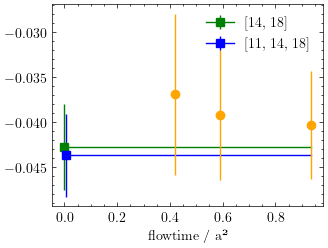

In [94]:
sub = (0,1)
iflows_list = {(0,1) : [[14,18], [11,14,18]], (0,1,2) : [[11,14], [11,12,14]]}[sub]
model = 'constant'

x_range = np.linspace(0, flowtimes[max(map(max,iflows_list))], 100)
colors = ['green', 'blue']
offset = 0.005

for i, iflows in enumerate(iflows_list):
    fit = do_fit(sub, iflows, model)
    plt.plot(x_range, [fit.fcn(x, fit.pmean) for x in x_range], color=colors[i])
    plt.errorbar(i*offset, fit.fcn(0, fit.pmean), fit.fcn(0, fit.p).sdev, color=colors[i], marker='s', label=str(iflows))
    if i == len(iflows_list)-1:
        plt.errorbar(fit.x, gv.mean(fit.y), gv.sdev(fit.y), linestyle='', marker='o', color='orange')

plt.xlabel('flowtime / a²')
plt.legend()
plt.show()

# Constant fits: diag approx for mean, bootstrap for sdev

In [ ]:
# TODO
# compute fit by: diagonal approx for mean, bootstrap for sdev
# check chi2 (using full cov) for results (does that make sense?)

# Linear and quadratic fits


linear fit for sub=(0, 1) and iflows=[11, 14, 18]
chi2/dof [dof] = 1.07 [1],    Q = 0.30
f(x) = a + bx,    a = -0.0437(73)b = -0.00003(381)

quadratic fit for sub=(0, 1) and iflows=[11, 14, 18]
chi2/dof [dof] = 1.06 [1],    Q = 0.30
f(x) = a + bx²,    a = -0.0441(59)b = 0.0003(22)


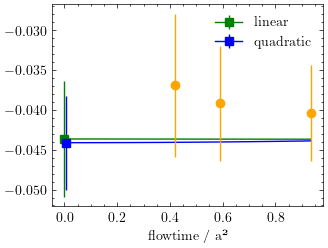

In [89]:
sub = (0,1)
iflows = {(0,1) : [11,14,18], (0,1,2) : [11,12,14]}[sub]
model_list = ['linear', 'quadratic']

x_range = np.linspace(0, flowtimes[max(iflows)], 100)
colors = ['green', 'blue']
offset = 0.005

for i, model in enumerate(model_list):
    fit = do_fit(sub, iflows, model)
    plt.plot(x_range, [fit.fcn(x, fit.pmean) for x in x_range], color=colors[i])
    plt.errorbar(i*offset, fit.fcn(0, fit.pmean), fit.fcn(0, fit.p).sdev, color=colors[i], marker='s', label=model)
    if i == len(model_list)-1:
        plt.errorbar(fit.x, gv.mean(fit.y), gv.sdev(fit.y), linestyle='', marker='o', color='orange')

plt.xlabel('flowtime / a²')
plt.legend()
plt.show()